<a href="https://colab.research.google.com/github/Utsa-HEP/Pythia_cc/blob/main/DD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phenomenological Search for Intrinsic Charm
**Author:** Utsa Dastidar

This notebook executes a full phenomenological pipeline to investigate the signatures of Intrinsic Charm in high-energy proton-proton collisions. The study simulates $p-p$ collisions at $\sqrt{s} = 13.6$ TeV using Pythia 8 and isolates heavy-flavor production ($D^0\bar{D}^0$ pairs) within the forward kinematic acceptance of the LHCb detector ($2.0 \leq \eta \leq 5.0$).

We compare a baseline perturbative QCD model (CT18NNLO) against a global fit containing an intrinsic charm component (NNPDF4.0). The primary objective of this phase is Monte Carlo event generation and the extraction of correlated multi-particle kinematics (such as azimuthal separation $\Delta\phi$, rapidity differences $\Delta y$, and invariant mass $m_{inv}$). The resulting datasets serve as the foundational observables for subsequent statistical analysis and signal isolation.

## Phase 1: Environment Setup & PDF Acquisition
Because Google Colab does not natively support high-energy physics libraries, we initialize a Miniforge environment using `condacolab`. We then install the Pythia 8 event generator and the LHAPDF6 library.

Finally, we download the specific Parton Distribution Function (PDF) grids required for the experiment:
* **CT18NNLO:** The baseline standard model PDF, where charm is generated purely dynamically via gluon splitting ($g \to c\bar{c}$).
* **NNPDF40_nnlo_as_01180:** The neural network PDF fit containing a fitted probability distribution for intrinsic, non-perturbative charm quarks in the proton wave function.

In [1]:
!pip install -q condacolab
import condacolab
condacolab.install()

⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:13
🔁 Restarting kernel...


In [ ]:
!conda install -y -c conda-forge python=3.12 pythia8 lhapdf pandas
import os
os.environ["LHAPDF_DATA_PATH"] = "/usr/local/share/LHAPDF"
!mkdir -p /usr/local/share/LHAPDF
!lhapdf install CT18NNLO
!lhapdf install NNPDF40_nnlo_as_01180

## Phase 2: Monte Carlo Event Generation
We simulate $100,000$ hard-QCD events for each PDF set. The generator is strictly forced to prioritize $gg \to c\bar{c}$ and $q\bar{q} \to c\bar{c}$ scatterings.

Instead of inclusive single-particle tracking, this phenomenological study relies on two-particle correlations. The script filters the final-state particles to isolate $D^0$ and $\bar{D}^0$ mesons falling strictly within the $2.0 \leq \eta \leq 5.0$ acceptance window.

In [1]:
import os
import pandas as pd
import numpy as np
import pythia8

os.environ["LHAPDF_DATA_PATH"] = "/usr/local/share/LHAPDF"
os.environ["PYTHIA8DATA"] = "/usr/local/share/Pythia8/xmldoc"

def generate_ddbar_events(pdf_set_name, output_csv):
    pythia = pythia8.Pythia()

    pythia.readString("Beams:idA = 2212")
    pythia.readString("Beams:idB = 2212")
    pythia.readString("Beams:eCM = 13600.")
    pythia.readString("PDF:pSet = LHAPDF6:" + pdf_set_name)
    pythia.readString("HardQCD:gg2ccbar = on")
    pythia.readString("HardQCD:qqbar2ccbar = on")

    if not pythia.init():
        print(f"Pythia failed to initialize for {pdf_set_name}!")
        return

    records = []
    num_events = 100000

    for iEvent in range(num_events):
        if not pythia.next():
            continue

        d0_candidates = []
        d0bar_candidates = []

        for particle in pythia.event:
            eta = particle.eta()
            if 2.0 <= eta <= 5.0:
                pid = particle.id()
                if pid == 421:
                    d0_candidates.append(particle)
                elif pid == -421:
                    d0bar_candidates.append(particle)

        for d1 in d0_candidates:
            for d2 in d0bar_candidates:
                dphi = abs(d1.phi() - d2.phi())
                if dphi > np.pi:
                    dphi = 2 * np.pi - dphi

                dy = abs(d1.y() - d2.y())

                e_tot = d1.e() + d2.e()
                px_tot = d1.px() + d2.px()
                py_tot = d1.py() + d2.py()
                pz_tot = d1.pz() + d2.pz()

                pt_pair = np.sqrt(px_tot**2 + py_tot**2)

                mass_sq = e_tot**2 - px_tot**2 - py_tot**2 - pz_tot**2
                m_inv = np.sqrt(mass_sq) if mass_sq > 0 else 0.0

                records.append({
                    "event_id": iEvent,
                    "pt_d1": d1.pT(),
                    "y_d1": d1.y(),
                    "phi_d1": d1.phi(),
                    "pt_d2": d2.pT(),
                    "y_d2": d2.y(),
                    "phi_d2": d2.phi(),
                    "delta_phi": dphi,
                    "delta_y": dy,
                    "pt_pair": pt_pair,
                    "m_inv": m_inv
                })

    cols = ["event_id", "pt_d1", "y_d1", "phi_d1", "pt_d2", "y_d2", "phi_d2", "delta_phi", "delta_y", "pt_pair", "m_inv"]
    df = pd.DataFrame(records, columns=cols)
    df.to_csv(output_csv, index=False)
    print(f"Saved {len(df)} D-Dbar pairs to {output_csv}")

generate_ddbar_events("CT18NNLO", "baseline_ddbar_pairs.csv")
generate_ddbar_events("NNPDF40_nnlo_as_01180", "ic_ddbar_pairs.csv")

Saved 4020 D-Dbar pairs to baseline_ddbar_pairs.csv
Saved 4130 D-Dbar pairs to ic_ddbar_pairs.csv


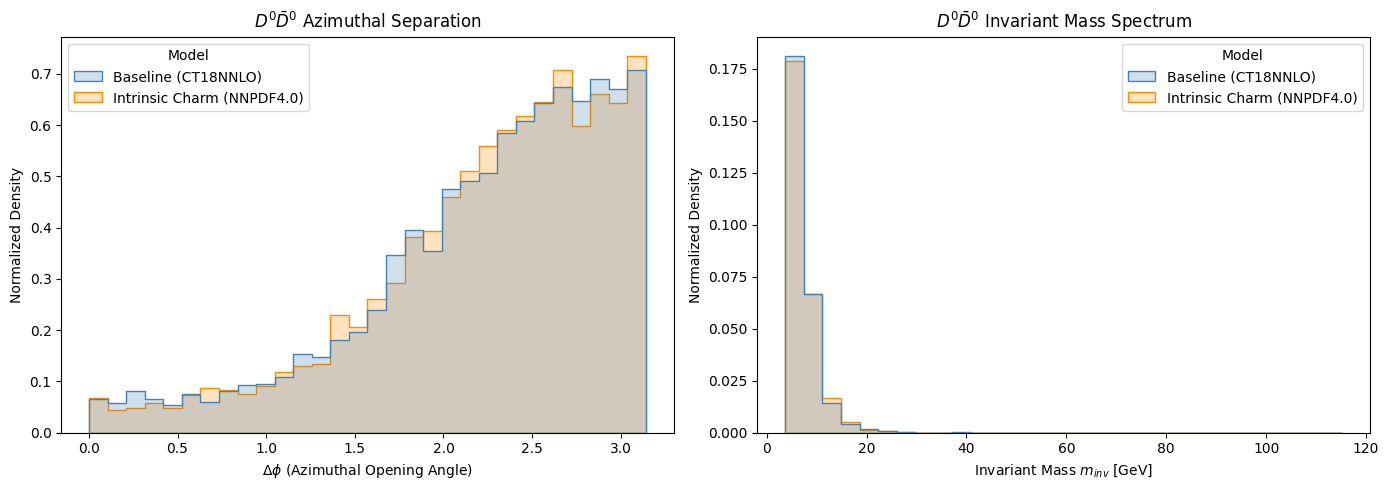

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_base = pd.read_csv("baseline_ddbar_pairs.csv")
df_ic = pd.read_csv("ic_ddbar_pairs.csv")

df_base['Model'] = 'Baseline (CT18NNLO)'
df_ic['Model'] = 'Intrinsic Charm (NNPDF4.0)'

df_combined = pd.concat([df_base, df_ic], ignore_index=True)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(
    data=df_combined,
    x='delta_phi',
    hue='Model',
    element='step',
    stat='density',
    common_norm=False,
    bins=30,
    palette=['steelblue', 'darkorange']
)
plt.xlabel(r'$\Delta\phi$ (Azimuthal Opening Angle)')
plt.ylabel('Normalized Density')
plt.title(r'$D^0\bar{D}^0$ Azimuthal Separation')

plt.subplot(1, 2, 2)
sns.histplot(
    data=df_combined,
    x='m_inv',
    hue='Model',
    element='step',
    stat='density',
    common_norm=False,
    bins=30,
    palette=['steelblue', 'darkorange']
)
plt.xlabel(r'Invariant Mass $m_{inv}$ [GeV]')
plt.ylabel('Normalized Density')
plt.title(r'$D^0\bar{D}^0$ Invariant Mass Spectrum')

plt.tight_layout()
plt.show()